In [66]:
import pandas as pd

# Tarea 1: Carga y exploración inicial


### Importa el CSV i analiza su estructura

In [67]:
df = pd.read_csv('dataset_movilidad_urbana.csv')

In [68]:
# observamos las 5 primeras filas del dataframe
df.head()

,fecha_hora,parada,num_pasajeros,tiempo_espera,evento_climatico
0,2024-03-11 00:00:00 19:00:00,Parada_8,6.0,9.5,soleado
1,2024-03-14 00:00:00 02:30:00,Parada_4,7.0,10.2,soleado
2,2024-03-27 00:00:00 01:30:00,Parada_4,6.0,5.1,tormenta
3,2024-03-21 00:00:00 06:30:00,Parada_8,7.0,1.8,tormenta
4,2024-03-23 00:00:00 23:00:00,Parada_7,7.0,4.9,tormenta


In [69]:
# información básica del dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha_hora        510 non-null    object 
 1   parada            510 non-null    object 
 2   num_pasajeros     485 non-null    float64
 3   tiempo_espera     485 non-null    float64
 4   evento_climatico  510 non-null    object 
dtypes: float64(2), object(3)
memory usage: 20.0+ KB


In [70]:
#estadísticas generales del dataframe
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_pasajeros,485.0,7.841237,2.590022,2.0,6.0,8.0,9.0,16.0
tiempo_espera,485.0,5.966598,2.915313,0.1,3.8,6.0,7.8,15.7


### Identifica valores nulos, duplicados y rangos atípicos en cada variable

In [71]:
# valores nulos por columnas
df.isna().sum()

fecha_hora           0
parada               0
num_pasajeros       25
tiempo_espera       25
evento_climatico     0
dtype: int64

In [ ]:
#valores duplicados
df.duplicated().sum()

# Tarea 2: Limpieza de datos


### Elimina duplicados y gestiona los valores nulos (imputación o eliminación justificada).


In [73]:
# Tenemos 50 valores nulos en total y 10 filas de datos repetidas.
# La variable parada la vamos a modificar para tener un valor numérico de cada parada, sin texto.

In [74]:
# eliminamos las filas de datos repetidas
df.drop_duplicates(inplace=True)

In [75]:
# comrpobamos que se han eliminado correctamente.
df.head().duplicated().sum()

np.int64(0)

In [77]:
# aplicamos imputación (codifiacion de etiquetas) para convertir la columna 'parada' a una variable numérica
df['parada_cod'] = df['parada'].str.extract('(\d+)').astype(int)
df.head(10)

,fecha_hora,parada,num_pasajeros,tiempo_espera,evento_climatico,parada_cod
0,2024-03-11 00:00:00 19:00:00,Parada_8,6.0,9.5,soleado,8
1,2024-03-14 00:00:00 02:30:00,Parada_4,7.0,10.2,soleado,4
2,2024-03-27 00:00:00 01:30:00,Parada_4,6.0,5.1,tormenta,4
3,2024-03-21 00:00:00 06:30:00,Parada_8,7.0,1.8,tormenta,8
4,2024-03-23 00:00:00 23:00:00,Parada_7,7.0,4.9,tormenta,7
5,2024-03-27 00:00:00 06:30:00,Parada_1,6.0,5.8,soleado,1
6,2024-03-03 00:00:00 01:30:00,Parada_8,11.0,3.0,lluvia,8
7,2024-03-15 00:00:00 21:30:00,Parada_9,4.0,4.5,lluvia,9
8,2024-03-22 00:00:00 17:30:00,Parada_5,8.0,10.6,soleado,5
9,2024-03-21 00:00:00 01:30:00,Parada_1,6.0,8.0,nublado,1


In [78]:
# comprovamos que la nueva columna sea numérica
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha_hora        500 non-null    object 
 1   parada            500 non-null    object 
 2   num_pasajeros     475 non-null    float64
 3   tiempo_espera     475 non-null    float64
 4   evento_climatico  500 non-null    object 
 5   parada_cod        500 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 27.3+ KB


In [79]:
# otra manera de convertir la variable parada en numérica. Definiendo una función que separe el texto después del '_'.
# Esto se puede hacer ya que todos tienen el mismo formato.
def get_parada_number(x):
    return x.split('_')[1]

df['parada2'] = df['parada'].map(get_parada_number).astype(int)

In [80]:
df.head(15)

,fecha_hora,parada,num_pasajeros,tiempo_espera,evento_climatico,parada_cod,parada2
0,2024-03-11 00:00:00 19:00:00,Parada_8,6.0,9.5,soleado,8,8
1,2024-03-14 00:00:00 02:30:00,Parada_4,7.0,10.2,soleado,4,4
2,2024-03-27 00:00:00 01:30:00,Parada_4,6.0,5.1,tormenta,4,4
3,2024-03-21 00:00:00 06:30:00,Parada_8,7.0,1.8,tormenta,8,8
4,2024-03-23 00:00:00 23:00:00,Parada_7,7.0,4.9,tormenta,7,7
5,2024-03-27 00:00:00 06:30:00,Parada_1,6.0,5.8,soleado,1,1
6,2024-03-03 00:00:00 01:30:00,Parada_8,11.0,3.0,lluvia,8,8
7,2024-03-15 00:00:00 21:30:00,Parada_9,4.0,4.5,lluvia,9,9
8,2024-03-22 00:00:00 17:30:00,Parada_5,8.0,10.6,soleado,5,5
9,2024-03-21 00:00:00 01:30:00,Parada_1,6.0,8.0,nublado,1,1


In [132]:
# Calculamos el Rango IQ para detectar posibles outliers

Q1 = df['tiempo_espera'].quantile(0.25)
Q3 = df['tiempo_espera'].quantile(0.75)
IQR = Q3 - Q1
low = Q1 - 1.5 * IQR #Límite inferior
high = Q3 + 1.5 * IQR #Límite superior

count_outliers_tiempo_espera = len(df[(df['tiempo_espera'] < low) | (df['tiempo_espera'] > high)])


In [133]:
count_outliers_tiempo_espera

3

In [136]:
# Una vez hemos definido cómo encontrar un outlier, vamos a diseñar una función para detectar outliers en cada una de nuestros datos

def count_outliers(df_):
    outliers_for_column = {}
    columns_to_analyze = ['num_pasajeros','tiempo_espera']
    for col in columns_to_analyze:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        low = Q1 - 1.5 * IQR #Límite inferior
        high = Q3 + 1.5 * IQR #Límite superior

        count_outliers_tiempo_espera = len(df[(df[col] < low) | (df[col] > high)])
        outliers_for_column[col] = count_outliers_tiempo_espera
    return outliers_for_column

In [137]:
# Definimos una variable nueva para una mejor interpretación de los resultados
num_outliers = count_outliers(df)
print(num_outliers)

{'num_pasajeros': 7, 'tiempo_espera': 3}


In [87]:
# Localizamos valores nulos
df.isna().sum()

fecha_hora           0
parada               0
num_pasajeros       25
tiempo_espera       25
evento_climatico     0
parada_cod           0
parada2              0
dtype: int64

In [88]:
# Se decide hacer imputación y no eliminación, ya que considero que se perderían bastantes datos (50 en ttoal).

In [89]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_pasajeros,475.0,7.816842,2.596275,2.0,6.0,8.0,9.0,16.0
tiempo_espera,475.0,5.961684,2.910828,0.1,3.8,6.0,7.8,15.7
parada_cod,500.0,5.510000,2.945378,1.0,3.0,5.0,8.0,10.0
parada2,500.0,5.510000,2.945378,1.0,3.0,5.0,8.0,10.0


In [90]:
# Se hace imputación y se asigna la media. Se hace un for loop para aplicarlo a cada una de nuestras columnas

columns_to_impute = ['num_pasajeros','tiempo_espera']
for col in columns_to_impute:
    df[col].fillna(df[col].mean(), inplace=True)

C:\Users\Victor Ferrer\AppData\Local\Temp\ipykernel_11224\108067554.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [91]:
# Se comprueba que slos valores nulos se han gestionado correctamente y ya no hay ninguno
df.isna().sum()

fecha_hora          0
parada              0
num_pasajeros       0
tiempo_espera       0
evento_climatico    0
parada_cod          0
parada2             0
dtype: int64

##  Verifica que las fechas sean coherentes y estén dentro del rango previsto.

In [92]:
# Visualizamos qué formato tiene la columna de 'fecha_hora'
df['fecha_hora'].head(100)

0     2024-03-11 00:00:00 19:00:00
1     2024-03-14 00:00:00 02:30:00
2     2024-03-27 00:00:00 01:30:00
3     2024-03-21 00:00:00 06:30:00
4     2024-03-23 00:00:00 23:00:00
                  ...             
95    2024-03-14 00:00:00 16:00:00
96    2024-03-29 00:00:00 23:00:00
97    2024-03-08 00:00:00 09:00:00
98    2024-03-10 00:00:00 08:00:00
99    2024-03-09 00:00:00 19:30:00
Name: fecha_hora, Length: 100, dtype: object

In [94]:
# Convertimos la columna 'fecha_hora' (string) a un formato de datos (datetime). Esto nos permite trabajar mejor con fechas.

df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])

C:\Users\Victor Ferrer\AppData\Local\Temp\ipykernel_11224\2236390352.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])


In [95]:
# Se comprueba que la transformación de la columna 'fecha_hora' se ha efectuado correctamente.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   fecha_hora        500 non-null    datetime64[ns]
 1   parada            500 non-null    object        
 2   num_pasajeros     500 non-null    float64       
 3   tiempo_espera     500 non-null    float64       
 4   evento_climatico  500 non-null    object        
 5   parada_cod        500 non-null    int64         
 6   parada2           500 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 31.2+ KB


In [97]:
# Se busca el dias más antiguo y más actual de nuestros datos, para ver de que fecha a que fecha van los datos.

min_date = df['fecha_hora'].min()
max_date = df['fecha_hora'].max()
print(min_date)
print(max_date)

2024-03-01 00:00:00
2024-03-30 23:30:00


## Revisa si hay paradas inextistentes o inconsistentes

In [98]:
#Revisa si hay paradas inexistentes o inconsistentes

In [99]:

df.head(10)

,fecha_hora,parada,num_pasajeros,tiempo_espera,evento_climatico,parada_cod,parada2
0,2024-03-11 19:00:00,Parada_8,6.0,9.5,soleado,8,8
1,2024-03-14 02:30:00,Parada_4,7.0,10.2,soleado,4,4
2,2024-03-27 01:30:00,Parada_4,6.0,5.1,tormenta,4,4
3,2024-03-21 06:30:00,Parada_8,7.0,1.8,tormenta,8,8
4,2024-03-23 23:00:00,Parada_7,7.0,4.9,tormenta,7,7
5,2024-03-27 06:30:00,Parada_1,6.0,5.8,soleado,1,1
6,2024-03-03 01:30:00,Parada_8,11.0,3.0,lluvia,8,8
7,2024-03-15 21:30:00,Parada_9,4.0,4.5,lluvia,9,9
8,2024-03-22 17:30:00,Parada_5,8.0,10.6,soleado,5,5
9,2024-03-21 01:30:00,Parada_1,6.0,8.0,nublado,1,1


In [100]:
# Se comprueba si hay alguna parada inexistente, es decir, si en alguna parada no hay datos o hay muy pocos (Todo OK).
df['parada'].value_counts()

parada
Parada_5     65
Parada_1     61
Parada_7     56
Parada_10    55
Parada_8     50
Parada_9     49
Parada_4     46
Parada_2     45
Parada_3     42
Parada_6     31
Name: count, dtype: int64

# TAREA 3: Transformación

## Crea nuevas variables: por ejemplo, hora, día_semana a partir de fecha_hora

In [101]:
# Se extrae el día de la semana de dos maneras. La primera numérica (0=Monday, 6=Sunday) por si hay que trabajar posteriormente con variable numérica, y la segunda manera con string con los días de la semana.

df['weekday'] = df['fecha_hora'].dt.weekday  # 0=Monday
df['weekday_name'] = df['fecha_hora'].dt.day_name()  # optional, Monday, Tuesday...



In [102]:
# Se extrae el año, el mes, el día y la hora .

df['year'] = df['fecha_hora'].dt.year
df['month'] = df['fecha_hora'].dt.month
df['day'] = df['fecha_hora'].dt.day
df['hour'] = df['fecha_hora'].dt.hour

In [103]:
# Se comprueba que se hayan generado correctamente las nuevas columnas de datos.
df.head()

,fecha_hora,parada,num_pasajeros,tiempo_espera,evento_climatico,parada_cod,parada2,weekday,weekday_name,year,month,day,hour
0,2024-03-11 19:00:00,Parada_8,6.0,9.5,soleado,8,8,0,Monday,2024,3,11,19
1,2024-03-14 02:30:00,Parada_4,7.0,10.2,soleado,4,4,3,Thursday,2024,3,14,2
2,2024-03-27 01:30:00,Parada_4,6.0,5.1,tormenta,4,4,2,Wednesday,2024,3,27,1
3,2024-03-21 06:30:00,Parada_8,7.0,1.8,tormenta,8,8,3,Thursday,2024,3,21,6
4,2024-03-23 23:00:00,Parada_7,7.0,4.9,tormenta,7,7,5,Saturday,2024,3,23,23


## Codifica variables categóricas (evento_climatico) con one-hot encoding o ordinal

In [104]:
# Se mira cuántas variables categóricas tiene la columna 'evento_climatico'.
df['evento_climatico'].value_counts()

evento_climatico
nublado     131
lluvia      129
soleado     126
tormenta    114
Name: count, dtype: int64

In [105]:
# Se realiza codificación ordinal, ya que consideramos que si que tiene importancia el orden, de peor (tormenta) a mejor (soleado)

orden_evento_climatico = {'tormenta': 0,'lluvia': 1, 'nublado': 2, 'soleado': 3}

df['evento_climatico_ordinal'] = df['evento_climatico'].map(orden_evento_climatico)

In [106]:
# Se comprueba que se ha generado correctamente la nueva columna con la codificación ordinal.
df.head()

,fecha_hora,parada,num_pasajeros,tiempo_espera,evento_climatico,parada_cod,parada2,weekday,weekday_name,year,month,day,hour,evento_climatico_ordinal
0,2024-03-11 19:00:00,Parada_8,6.0,9.5,soleado,8,8,0,Monday,2024,3,11,19,3
1,2024-03-14 02:30:00,Parada_4,7.0,10.2,soleado,4,4,3,Thursday,2024,3,14,2,3
2,2024-03-27 01:30:00,Parada_4,6.0,5.1,tormenta,4,4,2,Wednesday,2024,3,27,1,0
3,2024-03-21 06:30:00,Parada_8,7.0,1.8,tormenta,8,8,3,Thursday,2024,3,21,6,0
4,2024-03-23 23:00:00,Parada_7,7.0,4.9,tormenta,7,7,5,Saturday,2024,3,23,23,0


##  Escala los tiempos de espera si vas a aplicar técnicas estadísticas o clustering.


In [107]:
from sklearn.preprocessing import StandardScaler

In [108]:
# Se aplica StandardScaler para escalar los datos (en este caso la columna tiempo_espera)

numeric_cols = ['tiempo_espera']
scaler = StandardScaler()
df['tiempo_espera_escalados'] = scaler.fit_transform(df[numeric_cols])

In [109]:
# Se comprueba que se ha generado correctamente la nueva columna con los datos escalados
df.head()

,fecha_hora,parada,num_pasajeros,tiempo_espera,evento_climatico,parada_cod,parada2,weekday,weekday_name,year,month,day,hour,evento_climatico_ordinal,tiempo_espera_escalados
0,2024-03-11 19:00:00,Parada_8,6.0,9.5,soleado,8,8,0,Monday,2024,3,11,19,3,1.248464
1,2024-03-14 02:30:00,Parada_4,7.0,10.2,soleado,4,4,3,Thursday,2024,3,14,2,3,1.495453
2,2024-03-27 01:30:00,Parada_4,6.0,5.1,tormenta,4,4,2,Wednesday,2024,3,27,1,0,-0.304038
3,2024-03-21 06:30:00,Parada_8,7.0,1.8,tormenta,8,8,3,Thursday,2024,3,21,6,0,-1.468414
4,2024-03-23 23:00:00,Parada_7,7.0,4.9,tormenta,7,7,5,Saturday,2024,3,23,23,0,-0.374606


# TAREA 4: Análisis exploratorio


## ¿Qué paradas tienen más afluencia de pasajeros?

In [111]:
# Para saber qué parada tiene más afluencia de pasajeros, se calcula la media de pasajeros por parada, ya que si hacemos la suma vamos a tener un resultado incorrecto, pues no todas las paradas tienen el mismo numero de datos.

df.groupby("parada")['num_pasajeros'].mean().sort_values(ascending=False)

parada
Parada_6     8.316672
Parada_4     8.096751
Parada_5     8.055903
Parada_1     8.037170
Parada_7     7.907444
Parada_10    7.874258
Parada_3     7.852782
Parada_2     7.480749
Parada_9     7.434028
Parada_8     7.152674
Name: num_pasajeros, dtype: float64

In [112]:
# Se visualiza cuántos datos de pasajeros hay de cada parada.
df.groupby("parada")['num_pasajeros'].count().sort_values(ascending=False)

parada
Parada_5     65
Parada_1     61
Parada_7     56
Parada_10    55
Parada_8     50
Parada_9     49
Parada_4     46
Parada_2     45
Parada_3     42
Parada_6     31
Name: num_pasajeros, dtype: int64

## ¿Cómo varía el tiempo de espera según el clima?

In [113]:
# Se visualiza el tiempo de espera promedio en cada categoria de 'evento_climatico'
df.groupby('evento_climatico')['tiempo_espera'].mean()

evento_climatico
lluvia      5.881279
nublado     6.004823
soleado     5.709962
tormenta    6.281317
Name: tiempo_espera, dtype: float64

## ¿Qué franjas horarias presentan mayor congestión?

In [116]:
# Se visualiza la media de pasajeros que hay en cada hora.
df.groupby('hour')['num_pasajeros'].mean().sort_values(ascending=False)

hour
5     8.562500
21    8.538462
18    8.511735
13    8.315890
8     8.315789
10    8.181818
22    8.114508
7     8.108340
17    7.989825
14    7.969474
20    7.860805
9     7.767602
1     7.757427
23    7.712674
15    7.705564
0     7.600732
6     7.569307
11    7.500000
4     7.450702
16    7.421053
12    7.409091
3     7.082584
2     7.063066
19    6.524372
Name: num_pasajeros, dtype: float64

In [186]:
# Se definen 4 franjas horarias: madrugada 0-5, mañana 6-11, tarde 12-18, noche 19-24

def get_franja_horaria(hour):
    if hour >= 0 and hour <=5:
        return 'A Madrugada (0-5)'
    elif hour >= 6 and hour <= 11:
        return 'B Mañana (6-11)'
    elif hour >= 12 and hour <= 18:
        return 'C Tarde (12-18)'
    else:
        return 'D Noche (19-24)'
    
df['franja_horaria'] = df['hour'].map(get_franja_horaria)

In [197]:
# Se comprueba que se ha generado correctamente la nueva columna con su franja horaria correspondiente.
df.head()

,fecha_hora,parada,num_pasajeros,tiempo_espera,evento_climatico,parada_cod,parada2,weekday,weekday_name,year,month,day,hour,evento_climatico_ordinal,tiempo_espera_escalados,franja_horaria
0,2024-03-11 19:00:00,Parada_8,6.0,9.5,soleado,8,8,0,Monday,2024,3,11,19,3,1.248464,D Noche (19-24)
1,2024-03-14 02:30:00,Parada_4,7.0,10.2,soleado,4,4,3,Thursday,2024,3,14,2,3,1.495453,A Madrugada (0-5)
2,2024-03-27 01:30:00,Parada_4,6.0,5.1,tormenta,4,4,2,Wednesday,2024,3,27,1,0,-0.304038,A Madrugada (0-5)
3,2024-03-21 06:30:00,Parada_8,7.0,1.8,tormenta,8,8,3,Thursday,2024,3,21,6,0,-1.468414,B Mañana (6-11)
4,2024-03-23 23:00:00,Parada_7,7.0,4.9,tormenta,7,7,5,Saturday,2024,3,23,23,0,-0.374606,D Noche (19-24)


### Ver graficos tarea 5 para explicacion de que franjas horarios presentan mayor congestion

In [211]:
# Se calcula el numero de pasajeros medio en cada franja horaria.
df_group_franja_horaria_numpasajeros = df.groupby(['franja_horaria'])[['num_pasajeros']].mean()
df_group_franja_horaria_numpasajeros

,num_pasajeros
franja_horaria,
A Madrugada (0-5),7.528053
B Mañana (6-11),7.922988
C Tarde (12-18),7.928320
D Noche (19-24),7.883664


In [212]:
# Se calcula el tiempo de espera medio en cada franja horaria.
df_group_franja_horaria_tiempoespera = df.groupby(['franja_horaria'])[['tiempo_espera']].mean()
df_group_franja_horaria_tiempoespera

,tiempo_espera
franja_horaria,
A Madrugada (0-5),5.696707
B Mañana (6-11),5.985620
C Tarde (12-18),6.001005
D Noche (19-24),6.198976


# TAREA 5: Visualización


## Crea al menos tres gráficos útiles para comunicar hallazgos.

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns

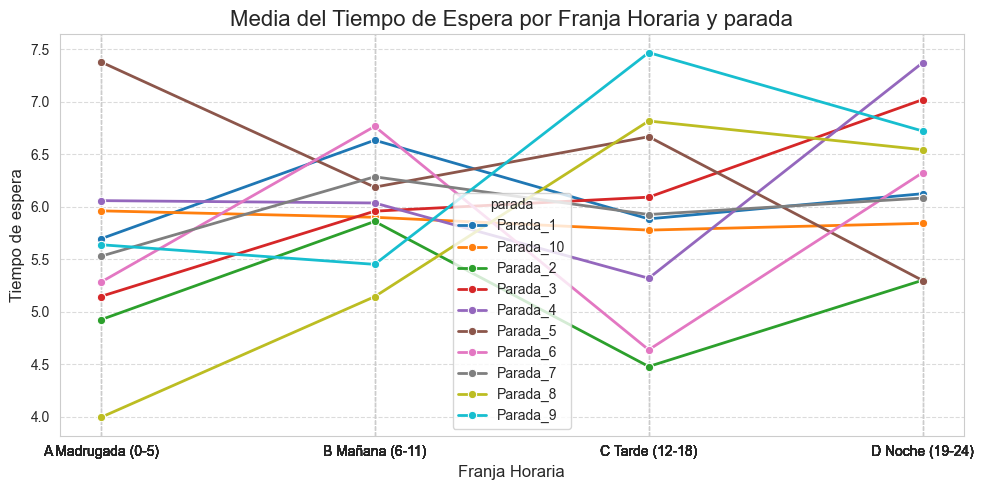

In [213]:
# Media del Tiempo de Espera por Franja Horaria y parada

demanda_horaria = df.groupby(['franja_horaria','parada'])['tiempo_espera'].mean().reset_index()

plt.figure(figsize=(10, 5))

# Gráfico de líneas
sns.lineplot(
    x='franja_horaria',
    y='tiempo_espera',
    data=demanda_horaria,
    hue='parada', 
    marker='o',
    linewidth=2,
)

plt.title('Media del Tiempo de Espera por Franja Horaria y parada', fontsize=16)
plt.xlabel('Franja Horaria', fontsize=12)
plt.ylabel('Tiempo de espera', fontsize=12)
plt.xticks(demanda_horaria['franja_horaria'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

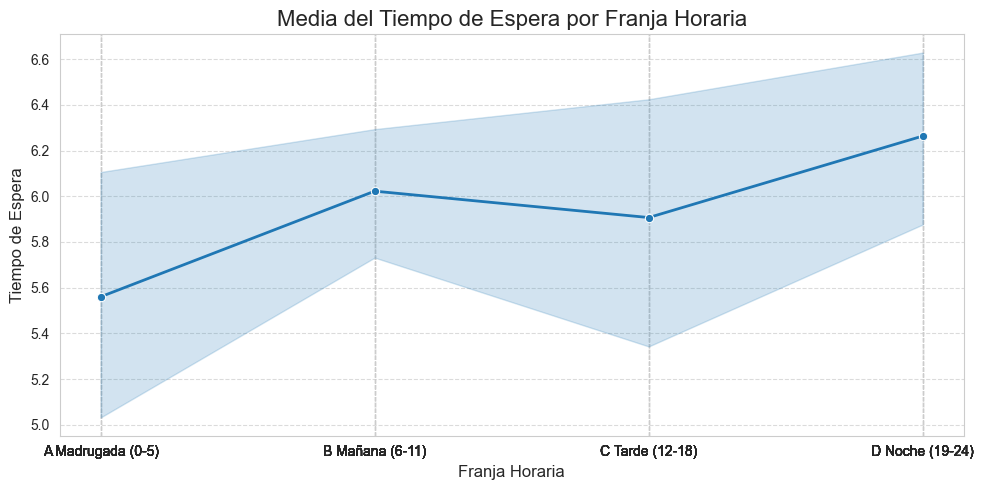

In [203]:
# Media del Tiempo de Espera por Franja Horaria

demanda_horaria = df.groupby(['franja_horaria','parada'])['tiempo_espera'].mean().reset_index()

plt.figure(figsize=(10, 5))

# Gráfico de líneas
sns.lineplot(
    x='franja_horaria',
    y='tiempo_espera',
    data=demanda_horaria,
    marker='o',
    linewidth=2,
)

plt.title('Media del Tiempo de Espera por Franja Horaria', fontsize=16)
plt.xlabel('Franja Horaria', fontsize=12)
plt.ylabel('Tiempo de Espera', fontsize=12)
plt.xticks(demanda_horaria['franja_horaria'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

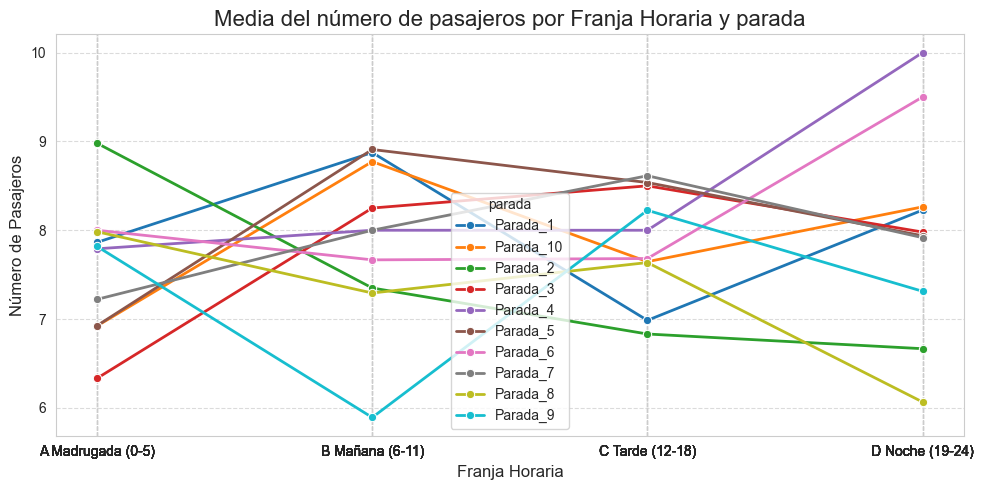

In [216]:
# Media del número de pasajeros por Franja Horaria y parada

demanda_horaria = df.groupby(['franja_horaria','parada'])['num_pasajeros'].mean().reset_index()

plt.figure(figsize=(10, 5))

# Crear el gráfico de líneas
sns.lineplot(
    x='franja_horaria',
    y='num_pasajeros',
    data=demanda_horaria,
    hue='parada', 
    marker='o',
    linewidth=2,
)

plt.title('Media del número de pasajeros por Franja Horaria y parada', fontsize=16)
plt.xlabel('Franja Horaria', fontsize=12)
plt.ylabel('Número de Pasajeros', fontsize=12)
plt.xticks(demanda_horaria['franja_horaria'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

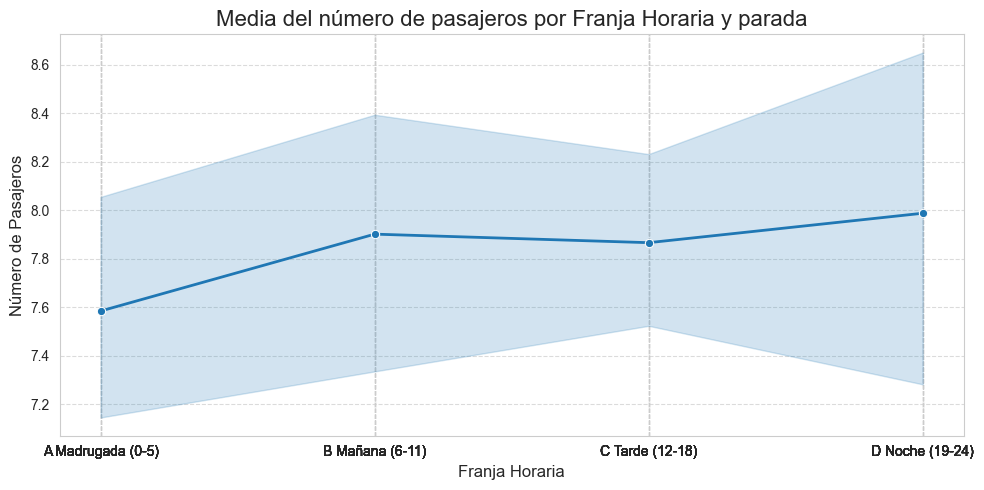

In [217]:
# Media del número de pasajeros por Franja Horaria y parada

demanda_horaria = df.groupby(['franja_horaria','parada'])['num_pasajeros'].mean().reset_index()

plt.figure(figsize=(10, 5))

# Crear el gráfico de líneas
sns.lineplot(
    x='franja_horaria',
    y='num_pasajeros',
    data=demanda_horaria,
    marker='o',
    linewidth=2,
)

plt.title('Media del número de pasajeros por Franja Horaria y parada', fontsize=16)
plt.xlabel('Franja Horaria', fontsize=12)
plt.ylabel('Número de Pasajeros', fontsize=12)
plt.xticks(demanda_horaria['franja_horaria'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [119]:
sns.set_style('whitegrid')
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

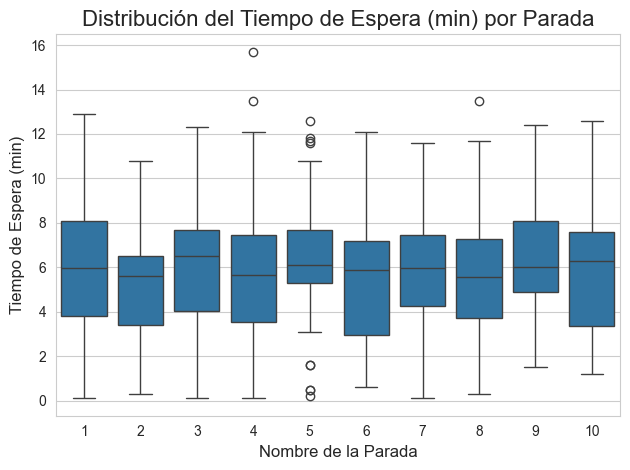

In [130]:
# Distribución del Tiempo de Espera (min) por Parada

sns.boxplot(x='parada2', y='tiempo_espera', data=df)

plt.title('Distribución del Tiempo de Espera (min) por Parada', fontsize=16)
plt.xlabel('Nombre de la Parada', fontsize=12)
plt.ylabel('Tiempo de Espera (min)', fontsize=12)
plt.tight_layout()
plt.show()